# CN7 OCSVM — 도메인 가설과 validation F1 기반 탐색

**선택 기준: 4-fold validation의 TP·FP·FN을 합산한 OOF F1 최대화.**

`F1 = 2TP / (2TP + FP + FN)`으로 미탐과 오탐을 함께 반영합니다. 정상 판정 수(TN)가 많다는 이유만으로 점수가 높아지지 않습니다. 별도의 오류 비용 가중치를 두지 않는 기본 목적함수이며 공식 대회 채점 지표나 운영 비용 최적임을 주장하지 않습니다.
FPR·AP·ROC-AUC는 참고 지표입니다. **FPR 상한으로 후보를 제외하거나 FPR로 순위를 정하지 않습니다.**

동률은 fold별 F1 표준편차가 작은 후보 → 입력 수가 적은 후보 순입니다. 여기까지 같으면 모델 후보 순서 → |t|이 작은 값 → 높은 t로 재현 가능하게 결정합니다. 마지막 규칙은 성능 우위를 뜻하지 않습니다.

## A. 학습·검증·선택 규칙

- 기존 패턴 단위 개발/test 분할과 4-fold를 유지합니다. 각 fold의 **정상 train 전체**로 전처리·파생변수·PCA·OCSVM을 적합합니다. 추가 보정 분할은 없습니다.
- 변수 구성과 `nu·gamma·숫자 임계값 t`를 함께 탐색합니다. 각 `(nu, gamma, t)`의 **동일한 t를 네 validation fold에 적용**하고 `-decision_function > t`로 판정합니다.
- 임계값 후보는 사전 고정한 `0`과 `±geomspace(1e-6, 1e3, 46)`, 총 93개입니다. 기본 경계와 여러 크기를 포함하는 탐색 범위이며 범위 자체의 최적성은 보장하지 않습니다.
- 각 fold F1의 단순 평균은 참고용입니다. **선택에는 합산 OOF F1**을 사용합니다. 불량이 fold당 2~3개뿐이므로 fold별 혼동행렬과 F1도 함께 확인합니다.
- 최종 조합을 확정한 뒤 개발 정상 전체로 재학습하고 선택된 t를 그대로 적용합니다. 재학습 후 원시 점수 척도가 달라질 수 있으며 test에서 확인합니다. Test로 t를 다시 고르지 않습니다.
- 여러 후보를 같은 개발 자료로 비교하므로 개발 선택 성능은 낙관적일 수 있습니다. 이전에 본 test의 후속 평가이며 독립 성능 검증은 새 자료가 필요합니다.

모델링 함수, 회귀 테스트, 산출물 감사 코드는 모두 이 노트북의 실행 셀에 포함되어 있습니다. 외부 프로젝트 `.py` import, `%run`, 스크립트 실행은 필요하지 않습니다. 필요한 것은 전처리 데이터·고정 분할 및 numpy/pandas/scikit-learn/matplotlib/joblib/nbformat/IPython 패키지입니다.

새 커널에서 위부터 전체 실행하면 탐색·평가·회귀 테스트·결과 감사를 수행합니다. 이전 생성·수정 스크립트의 역할은 이 노트북의 셀 구성과 그래프 코드로 반영했으며 셀 실행 중 노트북을 재생성하지 않습니다. 과거 AP/FPR 실험을 덮어쓰는 작업용 스크립트는 실행하지 않습니다.

이전 외부 모듈 기반 버전은 `archive/ocsvm_cn7_integrated_f1_external_20260929.ipynb`에 보존합니다. 결과는 `output/ocsvm_cn7_integrated/validation_f1_20260929/`에 저장합니다.

### A.1. 실행 환경과 라이브러리

In [1]:
from pathlib import Path
import os, sys, json, platform
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/origin').is_dir())
os.environ['MPLCONFIGDIR'] = str(ROOT/'tmp/matplotlib_cache')
import numpy as np
import pandas as pd
import sklearn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from pathlib import Path
import hashlib
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import nbformat
NOTEBOOK_PATH = ROOT/'modeling/ocsvm_cn7_integrated.ipynb'


### A.2. 탐색 후보와 공정 가설 정의

기존 Python 모듈의 설정을 직접 편집할 수 있는 셀로 옮겼습니다.

In [2]:
VERSION = 'domain_validation_f1_v3'
SEED = 42
# Explicit search grid, fixed before inspecting validation/test results.
# Includes OCSVM's default boundary 0 and both signs over nine orders of magnitude.
THRESHOLDS = np.r_[-np.geomspace(1e-6, 1e3, 46)[::-1], 0., np.geomspace(1e-6, 1e3, 46)].tolist()
NU_VALUES = sorted(set([0.001, 0.0025] + np.round(np.arange(1, 21)*0.005, 3).tolist()
                       + [0.125, 0.15, 0.20, 0.25, 0.30, 0.40]))
GAMMA_MULTIPLIERS = sorted(set(np.geomspace(0.03, 1., 15).tolist()
                              + [0.003, 0.005, 0.01, 0.02, 2., 3., 10.]))
GROUPS = {
    '충전과 전환': ['Injection_Time', 'Filling_Time', 'Cushion_Position',
                'Max_Injection_Speed', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure'],
    '계량과 가소화': ['Plasticizing_Time', 'Plasticizing_Position', 'Max_Screw_RPM',
                 'Average_Screw_RPM', 'Max_Back_Pressure', 'Average_Back_Pressure'],
    '실린더와 호퍼 온도': [f'Barrel_Temperature_{i}' for i in range(1, 7)] + ['Hopper_Temperature'],
    '금형 온도': ['Mold_Temperature_3', 'Mold_Temperature_4'],
    '형체와 전체 주기': ['Clamp_Close_Time', 'Clamp_Open_Position', 'Cycle_Time'],
}
SCENARIOS = {
    'raw': (),
    'legacy_without_cycle': (),
    'pressure': ('pressure',),
    'plasticizing': ('plasticizing',),
    'thermal': ('thermal',),
    'domain_all': ('pressure', 'plasticizing', 'thermal'),
    'group_pca': (),
}
DOMAIN_SPEC = [
    dict(feature='사출_전환압력_상대편차', group='pressure', operation='difference',
         columns=['Max_Injection_Pressure', 'Max_Switch_Over_Pressure'],
         hypothesis='최대 사출압력과 전환압력이 정상 대비 함께 변하는지 확인',
         limitation='서로 다른 시점의 요약값이며 실제 압력 강하가 아님', source='ARBURG 64/2017 p27'),
    dict(feature='스크루RPM_상대편차', group='plasticizing', operation='difference',
         columns=['Max_Screw_RPM', 'Average_Screw_RPM'],
         hypothesis='가소화 회전수의 최대·평균 상대 변화 불일치',
         limitation='실제 RPM 폭이나 시간적 변동성으로 해석할 수 없음', source='Sensors 2022 22(13):4792; 제공 변수명'),
    dict(feature='배압_상대편차', group='plasticizing', operation='difference',
         columns=['Max_Back_Pressure', 'Average_Back_Pressure'],
         hypothesis='가소화 배압의 최대·평균 상대 변화 불일치',
         limitation='실제 배압 차이 또는 불량 인과 효과가 아님', source='Sensors 2022 22(13):4792; 제공 변수명'),
    dict(feature='배럴_상대수준평균', group='thermal', operation='mean',
         columns=[f'Barrel_Temperature_{i}' for i in range(1, 7)],
         hypothesis='활성 배럴 센서의 정상 대비 공통 온도 이동',
         limitation='평균 섭씨 온도 아님; 센서 위치·목표 온도는 미확인', source='제공 변수명; 공정 가설'),
    dict(feature='배럴_상대편차표준편차', group='thermal', operation='std',
         columns=[f'Barrel_Temperature_{i}' for i in range(1, 7)],
         hypothesis='활성 배럴 센서의 정상 대비 변화가 서로 다른 정도',
         limitation='물리적 온도 균일도·공간 구배 아님', source='제공 변수명; 공정 가설'),
    dict(feature='금형_상대수준평균', group='thermal', operation='mean',
         columns=['Mold_Temperature_3', 'Mold_Temperature_4'],
         hypothesis='금형 센서의 정상 대비 공통 온도 이동',
         limitation='센서가 상·하형인지 미확인; 평균 섭씨 온도 아님', source='제공 변수명; 공정 가설'),
    dict(feature='금형온도_상대편차', group='thermal', operation='difference',
         columns=['Mold_Temperature_3', 'Mold_Temperature_4'],
         hypothesis='금형 두 센서의 정상 대비 상대 변화 불일치',
         limitation='실제 온도차·냉각 효율 아님', source='제공 변수명; 공정 가설'),
]


### A.3. 데이터·분할 무결성 확인 함수

In [3]:
def digest(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def write_json(path, record):
    Path(path).write_text(json.dumps(record, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')


def load_data(root):
    folder = Path(root)/'data/processed/cn7/conservative'
    split_folder = folder/'splits'
    manifest = json.loads((split_folder/'split_manifest.json').read_text(encoding='utf-8'))
    for filename, expected in manifest['source_sha256'].items():
        assert digest(folder/filename) == expected
    for filename, expected in manifest['artifact_sha256'].items():
        assert digest(split_folder/filename) == expected
    x = pd.read_csv(folder/'X_labeled.csv', float_precision='round_trip')
    y = pd.read_csv(folder/'y_labeled.csv').PassOrFail
    assignment = pd.read_csv(split_folder/'split_assignments.csv')
    assert sorted(x.columns) == sorted(sum(GROUPS.values(), []))
    assert np.isfinite(x.to_numpy()).all() and not x.duplicated().any()
    assert np.array_equal(assignment.pattern_row, np.arange(len(x)))
    assert np.array_equal(assignment.label, y) and assignment.pattern_id.is_unique
    assert set(y) == {0, 1}
    dev = assignment.loc[assignment.partition.eq('development'), 'pattern_row'].to_numpy()
    test = assignment.loc[assignment.partition.eq('test'), 'pattern_row'].to_numpy()
    assert not set(dev) & set(test) and set(dev) | set(test) == set(range(len(x)))
    assert set(assignment.loc[dev, 'cv_fold']) == {0, 1, 2, 3}
    assert assignment.loc[test, 'cv_fold'].eq(-1).all()
    return x, y, assignment, dev, test, manifest


In [4]:
def notebook_code_digest():
    saved = json.loads(NOTEBOOK_PATH.read_text(encoding='utf-8'))
    sources = [''.join(c['source']) for c in saved['cells'] if c['cell_type'] == 'code']
    return hashlib.sha256(json.dumps(sources, ensure_ascii=False).encode('utf-8')).hexdigest()


### A.4. 데이터 로드와 실행 설정 저장

In [5]:
OUT = ROOT/'output/ocsvm_cn7_integrated/validation_f1_20260929'
OUT.mkdir(parents=True, exist_ok=True)
# 탐색 후보와 F1 선택 규칙은 test 평가 전에 고정합니다.
print('선택 지표: 합산 OOF F1')
print('시나리오당', len(NU_VALUES)*len(GAMMA_MULTIPLIERS), '개 설정')
X, y, assignment, dev, test, source_manifest = load_data(ROOT)
Xdev, ydev = X.loc[dev].copy(), y.loc[dev].copy()
fold_ids = assignment.loc[dev, 'cv_fold'].copy()
print('개발:', len(dev), '위험:', int(ydev.sum()), '| 고정 test:', len(test))
old_roots = [ROOT/'output/ocsvm_cn7_integrated'/name for name in ['expanded_search_20260929','domain_fpr_20260929','validation_threshold_20260929']]
protected_hashes = {str(p.relative_to(ROOT)): digest(p) for old_root in old_roots for p in old_root.rglob('*') if p.is_file()}
write_json(OUT/'run_config.json', {
    'version': VERSION, 'source_sha256': source_manifest['source_sha256'],
    'split_sha256': digest(ROOT/'data/processed/cn7/conservative/splits/split_assignments.csv'),
    'implementation_source': 'inline notebook cells', 'notebook_code_sha256': notebook_code_digest(),
    'python': platform.python_version(), 'sklearn': sklearn.__version__,
    'selection_metric': 'pooled OOF F1', 'threshold_values': THRESHOLDS,
    'seed': SEED, 'scenarios': SCENARIOS})


선택 지표: 합산 OOF F1
시나리오당 616 개 설정
개발: 484 위험: 11 | 고정 test: 122


## B. 도메인 가설을 먼저 정의한 파생변수

제공 데이터는 컬럼별 표준화 값입니다. 아래 z는 **정상 적합 행 기준으로 다시 표준화한 상대 편차**입니다. 실제 초·bar·℃ 차이, 동력, 유량, 점도, 체적을 복원할 수 없습니다.

문헌은 공정 변수 간 관계를 뒷받침할 뿐, 아래 수식의 CN7 예측력이나 인과 효과를 검증하지 않았습니다. 수식은 명시적인 탐색 가설입니다.
사출압력과 전환의 관계는 [ARBURG 64/2017, p.27](https://www.arburg.com/media/daten/publications/today/Arburg_today64_2017_681763_en_gb.pdf), 가소화·사출 변수 구분은 [Liew 등, Sensors 2022](https://pmc.ncbi.nlm.nih.gov/articles/PMC9268792/)를 참고했습니다. 센서명은 제공 데이터와 저장소 용어 자료를 참고했습니다. 센서 위치·측정 시간창·실제 단위는 추가 확인이 필요합니다.

| 가설군 | 수식 | 확인하려는 상대 변화 |
|---|---|---|
| 충전·전환 | z(최대 사출압력) − z(전환압력) | 사출과 전환의 상대 변화 불일치 |
| 가소화 | z(최대 RPM) − z(평균 RPM), z(최대 배압) − z(평균 배압) | 최대·평균 상대 변화 불일치 |
| 열 상태 | 활성 배럴 z 평균·표준편차, 금형 z 평균·차이 | 센서들의 공통 이동과 상대 변화 차이 |

최대 7개를 정의하며 두 센서 이상이 실제 변할 때만 생성합니다. 배럴 센서의 상수값을 공간 분포에 포함하지 않습니다. 센서 활성 여부는 적합 행에서만 결정하며 적용 행에서 바꾸지 않습니다.
기존 속도×시간·압력·쿠션 및 계량시간×배압, 사출시간−충전시간은 물리 해석과 측정 정의가 불충분해 이번 후보에서 제외했습니다. 배럴 범위는 표준편차와 유사한 가설의 중복 추가를 줄이기 위해 제외했습니다.

원변수는 기본 유지합니다. `pressure`, `plasticizing`, `thermal`은 원변수+해당 가설군, `domain_all`은 원변수+전체 가설군입니다.
`legacy_without_cycle`은 과거 제외 효과를 확인하는 비교군이며 도메인 필수 삭제가 아닙니다. `group_pca`는 공정군별 PC 최대 2개와 잔차 RMSE를 사용하는 통계적 비교군입니다.


### B.1. 정상 train 적합 및 도메인 파생변수 변환 함수

In [6]:
def derived_frame(z, specs):
    result = pd.DataFrame(index=z.index)
    for spec in specs:
        values = z[spec['active_columns']]
        operation = spec['operation']
        if operation == 'difference':
            result[spec['feature']] = values.iloc[:, 0] - values.iloc[:, 1]
        elif operation == 'mean':
            result[spec['feature']] = values.mean(axis=1)
        elif operation == 'std':
            result[spec['feature']] = values.std(axis=1, ddof=0)
        else:
            raise ValueError(operation)
    return result


def unscaled_frame(bundle, inputs):
    inputs = inputs[bundle['input_columns']]
    z = pd.DataFrame(bundle['normal_scaler'].transform(inputs), index=inputs.index, columns=inputs.columns)
    if bundle['scenario'] == 'group_pca':
        frame = pd.DataFrame(index=inputs.index)
        for group, item in bundle['pcas'].items():
            values = z[item['columns']].to_numpy()
            scores = item['pca'].transform(values)
            for j in range(scores.shape[1]):
                frame[f'{group}_PC{j+1}'] = scores[:, j]
            if len(item['columns']) > scores.shape[1]:
                frame[f'{group}_재구성RMSE'] = np.sqrt(np.mean((values-item['pca'].inverse_transform(scores))**2, axis=1))
        return frame
    return pd.concat([z[bundle['base_columns']], derived_frame(z, bundle['specs'])], axis=1)


def fit_features(normal, scenario):
    if scenario not in SCENARIOS:
        raise ValueError(scenario)
    active = [c for c in normal if normal[c].nunique() > 1]
    scaler = StandardScaler().fit(normal)
    bundle = dict(scenario=scenario, input_columns=list(normal), normal_scaler=scaler,
                  specs=[], skipped_specs=[], pcas={})
    for spec in DOMAIN_SPEC:
        if spec['group'] not in SCENARIOS[scenario]:
            continue
        cols = [c for c in spec['columns'] if c in active]
        # Pairs need both sensors; aggregates need >=2 to avoid raw-feature duplication.
        if len(cols) < 2:
            bundle['skipped_specs'].append({'feature': spec['feature'], 'reason': '활성 센서 2개 미만'})
        else:
            bundle['specs'].append({**spec, 'active_columns': cols})
    bundle['base_columns'] = [c for c in active if scenario != 'legacy_without_cycle'
                              or c not in GROUPS['형체와 전체 주기']]
    if scenario == 'group_pca':
        z = pd.DataFrame(scaler.transform(normal), columns=normal.columns, index=normal.index)
        for group, cols in GROUPS.items():
            cols = [c for c in cols if c in active]
            if cols:
                bundle['pcas'][group] = {'columns': cols, 'pca': PCA(n_components=min(2, len(cols)),
                                                  svd_solver='full').fit(z[cols].to_numpy())}
    frame = unscaled_frame(bundle, normal)
    bundle['variance'] = VarianceThreshold(0).fit(frame)
    values = bundle['variance'].transform(frame)
    bundle['feature_scaler'] = StandardScaler().fit(values)
    bundle['feature_names'] = list(frame.columns[bundle['variance'].get_support()])
    return bundle, transform_features(bundle, normal)


def transform_features(bundle, inputs):
    frame = unscaled_frame(bundle, inputs)
    values = bundle['feature_scaler'].transform(bundle['variance'].transform(frame))
    assert np.isfinite(values).all()
    return values


In [7]:
domain_definitions = pd.DataFrame(DOMAIN_SPEC)
display(domain_definitions[['feature','group','operation','columns','hypothesis','limitation']])
display(pd.DataFrame([{'scenario': key, 'domain_groups': ', '.join(value) or '비교군'}
                      for key, value in SCENARIOS.items()]))


,feature,group,operation,columns,hypothesis,limitation
0,사출_전환압력_상대편차,pressure,difference,"[Max_Injection_Pressure, Max_Switch_Over_Press...",최대 사출압력과 전환압력이 정상 대비 함께 변하는지 확인,서로 다른 시점의 요약값이며 실제 압력 강하가 아님
1,스크루RPM_상대편차,plasticizing,difference,"[Max_Screw_RPM, Average_Screw_RPM]",가소화 회전수의 최대·평균 상대 변화 불일치,실제 RPM 폭이나 시간적 변동성으로 해석할 수 없음
2,배압_상대편차,plasticizing,difference,"[Max_Back_Pressure, Average_Back_Pressure]",가소화 배압의 최대·평균 상대 변화 불일치,실제 배압 차이 또는 불량 인과 효과가 아님
3,배럴_상대수준평균,thermal,mean,"[Barrel_Temperature_1, Barrel_Temperature_2, B...",활성 배럴 센서의 정상 대비 공통 온도 이동,평균 섭씨 온도 아님; 센서 위치·목표 온도는 미확인
4,배럴_상대편차표준편차,thermal,std,"[Barrel_Temperature_1, Barrel_Temperature_2, B...",활성 배럴 센서의 정상 대비 변화가 서로 다른 정도,물리적 온도 균일도·공간 구배 아님
5,금형_상대수준평균,thermal,mean,"[Mold_Temperature_3, Mold_Temperature_4]",금형 센서의 정상 대비 공통 온도 이동,센서가 상·하형인지 미확인; 평균 섭씨 온도 아님
6,금형온도_상대편차,thermal,difference,"[Mold_Temperature_3, Mold_Temperature_4]",금형 두 센서의 정상 대비 상대 변화 불일치,실제 온도차·냉각 효율 아님


,scenario,domain_groups
0,raw,비교군
1,legacy_without_cycle,비교군
2,pressure,pressure
3,plasticizing,plasticizing
4,thermal,thermal
5,domain_all,"pressure, plasticizing, thermal"
6,group_pca,비교군


## C. F1 기준 공동 탐색

7개 시나리오 × nu 28개 × gamma 배수 22개 × 4-fold = **17,248회 모델 적합**입니다. 각 모델의 validation 점수에 t 93개를 적용하여 **401,016개 조합**을 비교합니다. t만 바꿀 때는 재학습하지 않습니다.
실제 gamma는 배수를 입력 수로 나눕니다. 파생변수는 RBF 거리의 가중치도 바꾸므로 성능 변화가 새 정보 추가만을 의미하지 않습니다.

`threshold_search.csv`: 모든 조합의 합산 F1과 fold F1 표준편차 및 보조 지표.
`candidate_search.csv`: 모델 설정마다 F1 기준 최선 t의 결과.
`top_joint_candidates.csv`: 전체 조합 상위 20개. `top_model_candidates.csv`: 모델 설정별 대표 후보 상위 20개.


### C.1. 판정 지표·fold 계획·OCSVM 학습 함수

In [8]:
def classification_metrics(truth, prediction):
    truth, prediction = np.asarray(truth), np.asarray(prediction)
    tp = int(((truth == 1) & (prediction == 1)).sum())
    fn = int(((truth == 1) & (prediction == 0)).sum())
    fp = int(((truth == 0) & (prediction == 1)).sum())
    tn = int(((truth == 0) & (prediction == 0)).sum())
    return dict(TP=tp, FN=fn, FP=fp, TN=tn, recall=tp/(tp+fn) if tp+fn else 0.,
                FPR=fp/(fp+tn) if fp+tn else 0., precision=tp/(tp+fp) if tp+fp else 0.,
                F1=2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.,
                F2=5*tp/(5*tp+4*fn+fp) if 5*tp+4*fn+fp else 0.)


def make_fold_plan(xdev, ydev, fold_ids):
    assert xdev.index.equals(ydev.index) and xdev.index.equals(fold_ids.index)
    plans = []
    for fold in sorted(fold_ids.unique()):
        valid = xdev.index[fold_ids.eq(fold)].to_numpy()
        normal = xdev.index[fold_ids.ne(fold) & ydev.eq(0)].to_numpy()
        fit = normal.copy()
        assert not set(fit) & set(valid)
        assert ydev.loc[fit].eq(0).all()
        assert set(ydev.loc[valid]) == {0, 1}
        plans.append(dict(fold=int(fold), fit=fit, valid=valid))
    assert sorted(np.concatenate([p['valid'] for p in plans])) == sorted(xdev.index)
    return plans


def fit_model(values, nu, multiplier):
    model = OneClassSVM(kernel='rbf', nu=float(nu), gamma=float(multiplier)/values.shape[1],
                       tol=1e-4, max_iter=100000).fit(values)
    assert model.fit_status_ == 0, 'OCSVM 수렴 실패'
    return model


### C.2. F1 순위 규칙과 임계값별 validation 평가 함수

In [9]:
def rank_candidates(table):
    # FPR/AP/recall do not filter or rank candidates. Final keys make ties reproducible.
    return table.assign(threshold_distance=table.threshold.abs()).sort_values(
        ['F1', 'F1_std', 'feature_count', 'candidate_id', 'threshold_distance', 'threshold'],
        ascending=[False, True, True, True, True, False], kind='stable').drop(columns='threshold_distance')


def select_candidates(table):
    ranked = rank_candidates(table)
    if ranked.empty or ranked.iloc[0].F1 == 0:
        return [dict(status='no_supported_model', reason='개발 F1이 양수인 후보 없음')]
    return [{**ranked.iloc[0].to_dict(), 'status': 'selected_for_followup'}]


def threshold_trials(scored_folds, thresholds):
    """Evaluate the SAME fixed threshold on each validation fold, without refits."""
    thresholds = np.asarray(thresholds, dtype=float)
    if thresholds.ndim != 1 or not len(thresholds) or not np.isfinite(thresholds).all():
        raise ValueError('유한한 임계값 후보가 필요합니다.')
    totals = np.zeros((len(thresholds), 4), dtype=int)
    recalls, fprs, f1s = [], [], []
    for fold in scored_folds:
        truth, scores = np.asarray(fold['truth']), np.asarray(fold['scores'])
        assert len(truth) == len(scores) and np.isfinite(scores).all()
        prediction = scores[:, None] > thresholds[None, :]
        tp = prediction[truth == 1].sum(axis=0)
        fp = prediction[truth == 0].sum(axis=0)
        fn, tn = (truth == 1).sum()-tp, (truth == 0).sum()-fp
        totals += np.column_stack([tp, fp, fn, tn])
        recalls.append(tp/(tp+fn)); fprs.append(fp/(fp+tn))
        denom = 2*tp+fp+fn
        f1s.append(np.divide(2*tp, denom, out=np.zeros(len(tp), dtype=float), where=denom>0))
    tp, fp, fn, tn = totals.T
    return pd.DataFrame(dict(threshold=thresholds, TP=tp, FP=fp, FN=fn, TN=tn,
        recall=tp/(tp+fn), FPR=fp/(fp+tn),
        F1=2*tp/(2*tp+fp+fn), F1_std=np.std(f1s, axis=0, ddof=1),
        mean_fold_F1=np.mean(f1s, axis=0), worst_fold_F1=np.min(f1s, axis=0),
        precision=np.divide(tp, tp+fp, out=np.zeros(len(tp), dtype=float), where=(tp+fp)>0),
        recall_std=np.std(recalls, axis=0, ddof=1), worst_fold_recall=np.min(recalls, axis=0),
        max_fold_FPR=np.max(fprs, axis=0),
        mean_AP_reference=np.mean([f['AP_reference'] for f in scored_folds]),
        mean_ROC_AUC_reference=np.mean([f['ROC_AUC_reference'] for f in scored_folds])))


### C.3. 전체 하이퍼파라미터 탐색 함수

In [10]:
def search_development(xdev, ydev, fold_ids, out, nu_values=NU_VALUES,
                       multipliers=GAMMA_MULTIPLIERS, scenarios=None,
                       thresholds=THRESHOLDS):
    out = Path(out)
    out.mkdir(parents=True, exist_ok=True)
    plans = make_fold_plan(xdev, ydev, fold_ids)
    write_json(out/'fold_plan.json', [{k: v.tolist() if isinstance(v, np.ndarray) else v
                                     for k, v in plan.items()} for plan in plans])
    rows, audit, fold_rows, top_trials = [], [], [], []
    candidate_id = 0
    for scenario in (list(SCENARIOS) if scenarios is None else scenarios):
        cache, scenario_trials = [], []
        for plan in plans:
            bundle, train = fit_features(xdev.loc[plan['fit']], scenario)
            valid = transform_features(bundle, xdev.loc[plan['valid']])
            cache.append((plan, train, valid))
            audit.append(dict(scenario=scenario, fold=plan['fold'], fit_count=len(train),
                              validation_count=len(valid),
                              feature_names=bundle['feature_names'], domain_specs=bundle['specs'],
                              skipped_specs=bundle['skipped_specs']))
        for nu in nu_values:
            for multiplier in multipliers:
                scored_folds = []
                for plan, train, valid in cache:
                    model = fit_model(train, nu, multiplier)
                    scores = -model.decision_function(valid)
                    assert np.isfinite(scores).all()
                    truth = ydev.loc[plan['valid']].to_numpy()
                    refs = dict(AP_reference=float(average_precision_score(truth, scores)),
                                ROC_AUC_reference=float(roc_auc_score(truth, scores)))
                    scored_folds.append(dict(fold=plan['fold'], truth=truth, scores=scores, **refs))
                trials = threshold_trials(scored_folds, thresholds).assign(candidate_id=candidate_id,
                    scenario=scenario, nu=float(nu), gamma_multiplier=float(multiplier),
                    feature_count=max(c[1].shape[1] for c in cache))
                scenario_trials.append(trials)
                # Compress only after evaluating all t: exact best t per model by F1.
                # Full joint search remains available in threshold_search.csv.
                chosen = rank_candidates(trials).iloc[0].to_dict()
                rows.append(chosen)
                threshold = chosen['threshold']
                for scored in scored_folds:
                    row = dict(candidate_id=candidate_id, scenario=scenario, nu=float(nu),
                               gamma_multiplier=float(multiplier), fold=scored['fold'], threshold=threshold,
                               **classification_metrics(scored['truth'], scored['scores'] > threshold),
                               AP_reference=scored['AP_reference'], ROC_AUC_reference=scored['ROC_AUC_reference'])
                    fold_rows.append(row)
                candidate_id += 1
        first = candidate_id == len(nu_values)*len(multipliers)
        top_trials.append(rank_candidates(pd.concat(scenario_trials, ignore_index=True)).head(20))
        pd.concat(scenario_trials, ignore_index=True).to_csv(out/'threshold_search.csv', index=False,
                                                            mode='w' if first else 'a', header=first)
        print(f'{scenario}: {len(nu_values)*len(multipliers)}개 설정 × {len(plans)} folds 완료', flush=True)
        pd.DataFrame(rows).to_csv(out/'candidate_search.csv', index=False)
    table = pd.DataFrame(rows)
    folds = pd.DataFrame(fold_rows)
    folds.to_csv(out/'candidate_fold_metrics.csv', index=False)
    write_json(out/'feature_audit.json', audit)
    write_json(out/'domain_feature_definitions.json', DOMAIN_SPEC)
    rank_candidates(pd.concat(top_trials, ignore_index=True)).head(20).to_csv(out/'top_joint_candidates.csv', index=False)
    rank_candidates(table).head(20).to_csv(out/'top_model_candidates.csv', index=False)
    selected = select_candidates(table)
    write_json(out/'selection_manifest.json', dict(version=VERSION,
        selection='joint scenario/nu/gamma/threshold validation search; pooled OOF F1 max; ties fold F1 std, feature_count, candidate_id, abs(threshold), higher threshold',
        threshold='fixed numerical grid; same t across all folds and full development refit; risk > t',
        threshold_values=list(thresholds), train_normal_usage='all fold-training normals', choices=selected,
        test_used_for_selection=False, independent_validation=False,
        FPR_used_for_selection=False, AP_used_for_selection=False,
        nu_values=list(nu_values), gamma_multipliers=list(multipliers)))
    return table, folds, selected, plans


In [11]:
search, fold_search, selected, plans = search_development(Xdev, ydev, fold_ids, OUT)
expected = len(SCENARIOS)*len(NU_VALUES)*len(GAMMA_MULTIPLIERS)
assert len(search) == expected and len(fold_search) == expected*4
assert all(not (set(p['fit']) | set(p['valid'])) & set(test) for p in plans)
assert all(set(p['fit']) == set(Xdev.index[fold_ids.ne(p['fold']) & ydev.eq(0)]) for p in plans)
print('모델 적합:', expected*4, '| 임계값 포함 조합:', expected*len(THRESHOLDS))
print('fold별 정상 train 전체 행 수:', [len(p['fit']) for p in plans])
display(pd.DataFrame(selected))


raw: 616개 설정 × 4 folds 완료
legacy_without_cycle: 616개 설정 × 4 folds 완료
pressure: 616개 설정 × 4 folds 완료
plasticizing: 616개 설정 × 4 folds 완료
thermal: 616개 설정 × 4 folds 완료
domain_all: 616개 설정 × 4 folds 완료
group_pca: 616개 설정 × 4 folds 완료
모델 적합: 17248 | 임계값 포함 조합: 401016
fold별 정상 train 전체 행 수: [354, 355, 355, 355]


,threshold,TP,FP,FN,TN,recall,FPR,F1,F1_std,mean_fold_F1,worst_fold_F1,precision,recall_std,worst_fold_recall,max_fold_FPR,mean_AP_reference,mean_ROC_AUC_reference,candidate_id,scenario,nu,gamma_multiplier,feature_count,status
0,0.002512,4,1,7,472,0.363636,0.002114,0.5,0.0,0.5,0.5,0.8,0.083333,0.333333,0.008403,0.361354,0.810325,621,legacy_without_cycle,0.001,0.038539,21,selected_for_followup


## D. 가설군 비교와 F1 선택 근거

모든 가설군·파라미터·t를 동일한 합산 F1 기준으로 비교합니다. FPR은 결과 확인용이며 후보 제외 조건이 아닙니다.
가설군별 대표 후보, 모델 설정별 상위 20개, 전체 조합 상위 20개를 제공합니다. 같은 모델에서 여러 t가 동일 예측을 내면 공동 순위 후보가 생길 수 있습니다.
히트맵은 각 `(nu, gamma)`에서 선택한 t의 합산 F1입니다. 별도로 선택된 모델의 t별 F1·정밀도·재현율을 보여줍니다.


가설군별 대표 후보
모델 설정별 상위 20개
전체 조합 상위 20개


,scenario,nu,gamma_multiplier,threshold,F1,F1_std,mean_fold_F1,precision,recall,TP,FP,FN,TN,FPR,feature_count
1,legacy_without_cycle,0.001,0.038539,0.002512,0.500000,0.000000,0.500000,0.800000,0.363636,4,1,7,472,0.002114,21
4,thermal,0.005,0.049508,0.015849,0.444444,0.083333,0.458333,0.571429,0.363636,4,3,7,470,0.006342,27
6,group_pca,0.150,0.285835,25.118864,0.428571,0.250000,0.375000,1.000000,0.272727,3,0,8,473,0.000000,13
0,raw,0.001,0.063599,0.003981,0.421053,0.081650,0.433333,0.500000,0.363636,4,4,7,469,0.008457,23
2,pressure,0.001,0.063599,0.003981,0.421053,0.081650,0.433333,0.500000,0.363636,4,4,7,469,0.008457,24
3,plasticizing,0.001,0.471703,0.015849,0.421053,0.081650,0.433333,0.500000,0.363636,4,4,7,469,0.008457,25
5,domain_all,0.001,0.471703,0.015849,0.421053,0.081650,0.433333,0.500000,0.363636,4,4,7,469,0.008457,30


,scenario,nu,gamma_multiplier,threshold,F1,F1_std,mean_fold_F1,precision,recall,TP,FP,FN,TN,FPR,feature_count
0,legacy_without_cycle,0.0010,0.038539,0.002512,0.500000,0.000000,0.500000,0.800000,0.363636,4,1,7,472,0.002114,21
1,legacy_without_cycle,0.0025,0.038539,0.006310,0.500000,0.000000,0.500000,0.800000,0.363636,4,1,7,472,0.002114,21
2,legacy_without_cycle,0.0800,2.000000,0.630957,0.500000,0.070470,0.492857,0.555556,0.454545,5,4,6,469,0.008457,21
3,legacy_without_cycle,0.1250,2.000000,1.000000,0.500000,0.070470,0.492857,0.555556,0.454545,5,4,6,469,0.008457,21
4,legacy_without_cycle,0.2000,3.000000,1.000000,0.476190,0.101015,0.476190,0.500000,0.454545,5,5,6,468,0.010571,21
5,legacy_without_cycle,0.0010,0.063599,0.003981,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
6,legacy_without_cycle,0.0010,0.081701,0.003981,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
7,legacy_without_cycle,0.0010,0.104956,0.006310,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
8,legacy_without_cycle,0.0010,0.134829,0.006310,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
9,legacy_without_cycle,0.0010,0.173205,0.010000,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21


,scenario,nu,gamma_multiplier,threshold,F1,F1_std,mean_fold_F1,precision,recall,TP,FP,FN,TN,FPR,feature_count
0,legacy_without_cycle,0.0010,0.038539,0.002512,0.500000,0.000000,0.500000,0.800000,0.363636,4,1,7,472,0.002114,21
1,legacy_without_cycle,0.0025,0.038539,0.006310,0.500000,0.000000,0.500000,0.800000,0.363636,4,1,7,472,0.002114,21
2,legacy_without_cycle,0.0800,2.000000,0.630957,0.500000,0.070470,0.492857,0.555556,0.454545,5,4,6,469,0.008457,21
3,legacy_without_cycle,0.1250,2.000000,1.000000,0.500000,0.070470,0.492857,0.555556,0.454545,5,4,6,469,0.008457,21
4,legacy_without_cycle,0.2000,3.000000,1.000000,0.476190,0.101015,0.476190,0.500000,0.454545,5,5,6,468,0.010571,21
5,legacy_without_cycle,0.0010,0.063599,0.003981,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
6,legacy_without_cycle,0.0010,0.081701,0.003981,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
7,legacy_without_cycle,0.0010,0.104956,0.006310,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
8,legacy_without_cycle,0.0010,0.134829,0.006310,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21
9,legacy_without_cycle,0.0010,0.173205,0.010000,0.470588,0.050000,0.475000,0.666667,0.363636,4,2,7,471,0.004228,21


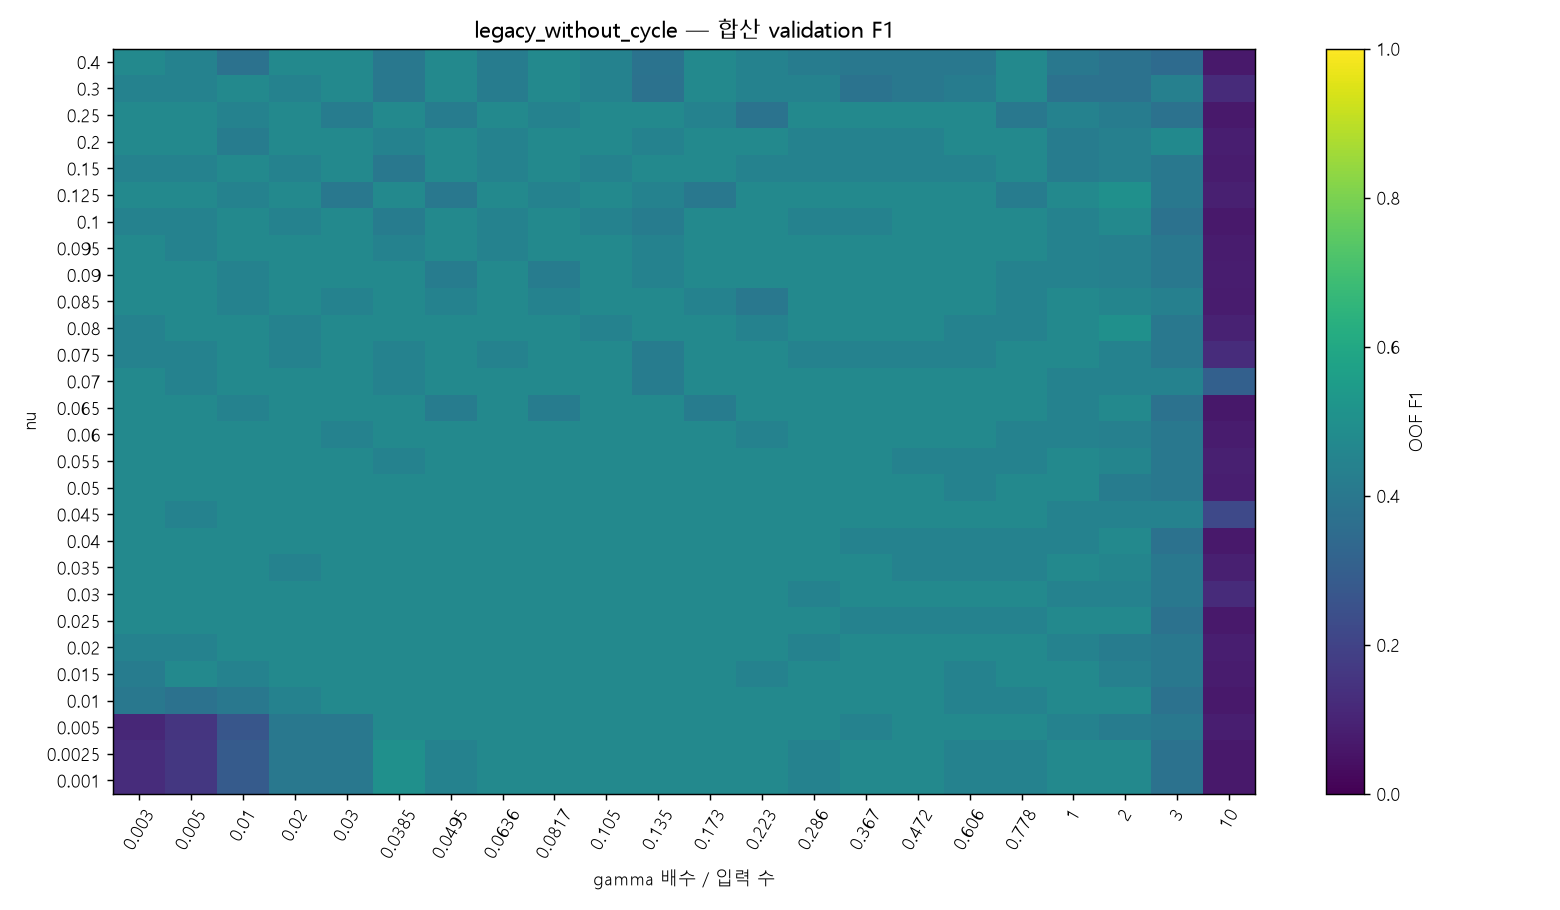

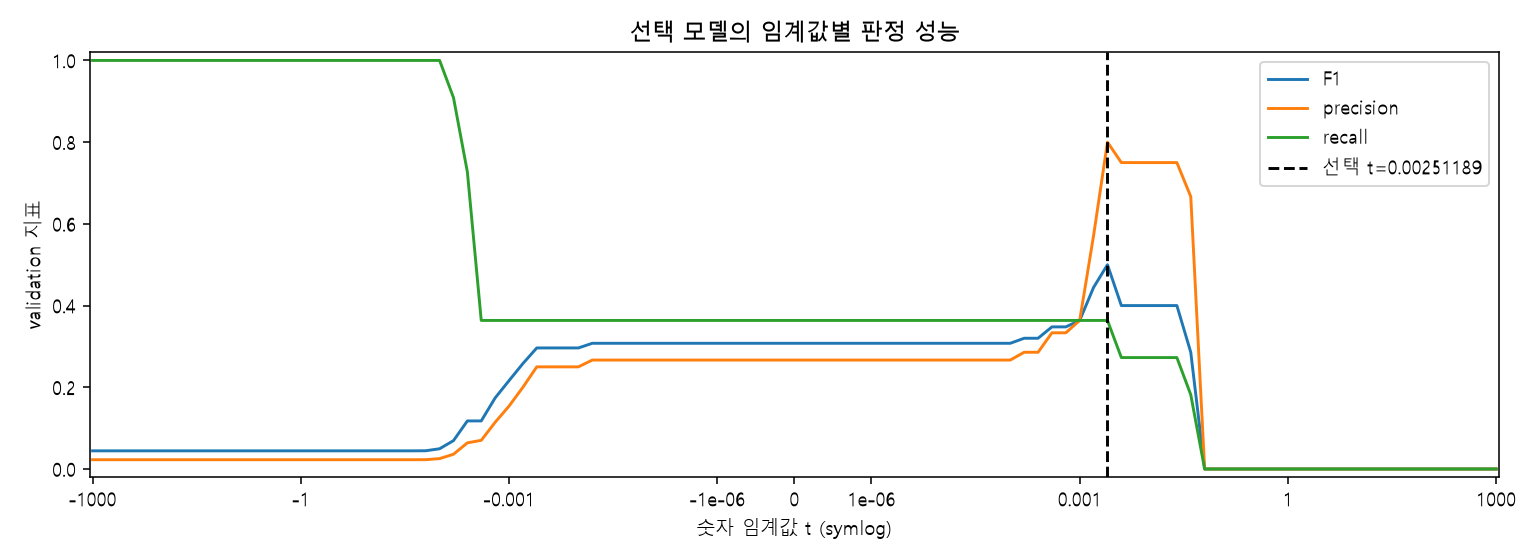

In [12]:
columns = ['scenario','nu','gamma_multiplier','threshold','F1','F1_std','mean_fold_F1',
           'precision','recall','TP','FP','FN','TN','FPR','feature_count']
scenario_comparison = pd.DataFrame([rank_candidates(part).iloc[0].to_dict()
    for _, part in search.groupby('scenario', sort=False)])
scenario_comparison = rank_candidates(scenario_comparison)
scenario_comparison.to_csv(OUT/'scenario_comparison.csv', index=False)
print('가설군별 대표 후보'); display(scenario_comparison[columns])
top_models = pd.read_csv(OUT/'top_model_candidates.csv', float_precision='round_trip')
top_joint = pd.read_csv(OUT/'top_joint_candidates.csv', float_precision='round_trip')
print('모델 설정별 상위 20개'); display(top_models[columns])
print('전체 조합 상위 20개'); display(top_joint[columns])
choice = selected[0]
if choice['status'] == 'selected_for_followup':
    part = search.loc[search.scenario.eq(choice['scenario'])]
    matrix = part.pivot(index='nu', columns='gamma_multiplier', values='F1')
    fig, ax = plt.subplots(figsize=(12,7))
    im = ax.imshow(matrix.to_numpy(), origin='lower', aspect='auto', vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(matrix.columns)), [f'{v:.3g}' for v in matrix.columns], rotation=60)
    ax.set_yticks(range(len(matrix.index)), [f'{v:.4g}' for v in matrix.index])
    ax.set(xlabel='gamma 배수 / 입력 수', ylabel='nu', title=choice['scenario']+' — 합산 validation F1')
    fig.colorbar(im, ax=ax, label='OOF F1'); fig.tight_layout()
    fig.savefig(OUT/'f1_heatmap.png', dpi=130); plt.close(fig)
    display(Image(filename=str(OUT/'f1_heatmap.png')))
    sensitivity = pd.concat([chunk.loc[chunk.candidate_id.eq(choice['candidate_id'])]
        for chunk in pd.read_csv(OUT/'threshold_search.csv', chunksize=50000, float_precision='round_trip')])
    sensitivity.to_csv(OUT/'selected_threshold_sensitivity.csv', index=False)
    fig, ax = plt.subplots(figsize=(11,4))
    for metric in ['F1','precision','recall']: ax.plot(sensitivity.threshold, sensitivity[metric], label=metric)
    ax.axvline(choice['threshold'], color='black', ls='--', label=f"선택 t={choice['threshold']:.6g}")
    ax.set_xscale('symlog', linthresh=1e-6)
    ticks = [-1e3,-1.,-1e-3,-1e-6,0.,1e-6,1e-3,1.,1e3]
    ax.set_xticks(ticks, [f'{v:g}' for v in ticks])
    ax.minorticks_off()
    ax.set(xlabel='숫자 임계값 t (symlog)', ylabel='validation 지표', ylim=(-.02,1.02), title='선택 모델의 임계값별 판정 성능')
    ax.legend(); fig.tight_layout(); fig.savefig(OUT/'threshold_sensitivity.png', dpi=140); plt.close(fig)
    display(Image(filename=str(OUT/'threshold_sensitivity.png')))


## E. 개발 OOF 재현 및 공정군 중요도 진단

선택한 t를 고정하고 검증 원변수의 공정군을 섞은 뒤 파생변수를 다시 계산합니다. **F1 감소량**을 중심으로 재현율 감소·FPR 증가도 기록합니다. 중요도는 진단용이며 후보 추가·삭제·재선택에 사용하지 않습니다. 변수군 간 상관이 깨지므로 인과 효과로 해석하지 않습니다.


In [13]:
def development_diagnostics(xdev, ydev, plans, selected, out, repeats=20):
    """Group permutation diagnostic. Recompute derived features from raw inputs.

    Fixed model + validation-selected threshold; report F1 loss and supporting metrics.
    This diagnostic never generates new candidates or changes selection.
    """
    predictions, importance = [], []
    selection_sha = digest(Path(out)/'selection_manifest.json')
    for choice in selected:
        if choice['status'] != 'selected_for_followup':
            continue
        for plan in plans:
            bundle, train = fit_features(xdev.loc[plan['fit']], choice['scenario'])
            model = fit_model(train, choice['nu'], choice['gamma_multiplier'])
            threshold = float(choice['threshold'])
            inputs = xdev.loc[plan['valid']]
            truth = ydev.loc[plan['valid']].to_numpy()
            scores = -model.decision_function(transform_features(bundle, inputs))
            base = classification_metrics(truth, scores > threshold)
            for index, label, score in zip(inputs.index, truth, scores):
                predictions.append(dict(scenario=choice['scenario'],
                    fold=plan['fold'], pattern_row=int(index), y_true=int(label), risk_score=float(score),
                    threshold=threshold, y_pred=int(score > threshold)))
            for group, cols in GROUPS.items():
                rng = np.random.default_rng(SEED+plan['fold'])
                for repeat in range(repeats):
                    perm = inputs.copy()
                    perm.loc[:, cols] = inputs[cols].to_numpy()[rng.permutation(len(inputs))]
                    changed_scores = -model.decision_function(transform_features(bundle, perm))
                    changed = classification_metrics(truth, changed_scores > threshold)
                    importance.append(dict(scenario=choice['scenario'],
                        fold=plan['fold'], group=group, repeat=repeat,
                        F1_drop=base['F1']-changed['F1'], recall_drop=base['recall']-changed['recall'], FPR_increase=changed['FPR']-base['FPR']))
    pred = pd.DataFrame(predictions, columns=['scenario','fold','pattern_row','y_true','risk_score','threshold','y_pred'])
    imp = pd.DataFrame(importance, columns=['scenario','fold','group','repeat','F1_drop','recall_drop','FPR_increase'])
    pred.to_csv(Path(out)/'selected_oof_predictions.csv', index=False)
    imp.to_csv(Path(out)/'group_importance_repeats.csv', index=False)
    assert digest(Path(out)/'selection_manifest.json') == selection_sha
    return pred, imp


In [14]:
oof_predictions, importance = development_diagnostics(Xdev, ydev, plans, selected, OUT)
if not importance.empty:
    importance_summary = importance.groupby(['scenario','group'], as_index=False).agg(
        mean_F1_drop=('F1_drop','mean'), mean_recall_drop=('recall_drop','mean'), mean_FPR_increase=('FPR_increase','mean'))
    importance_summary.to_csv(OUT/'group_importance_summary.csv', index=False)
    display(importance_summary)
if choice['status'] == 'selected_for_followup':
    p = oof_predictions
    assert len(p) == len(dev) and p.pattern_row.is_unique
    observed = classification_metrics(p.y_true, p.y_pred)
    assert all(observed[k] == choice[k] for k in ['TP','FP','FN','TN','F1'])
    assert p.threshold.eq(choice['threshold']).all()
    selected_folds = fold_search.loc[fold_search.candidate_id.eq(choice['candidate_id'])]
    selected_folds.to_csv(OUT/'selected_fold_metrics.csv', index=False)
    display(selected_folds[['fold','threshold','F1','precision','recall','TP','FP','FN','TN','FPR']])
selection_sha = digest(OUT/'selection_manifest.json')
print('선택 확정 해시:', selection_sha)


선택 확정 해시: 99d987253ddf4893d988b007ed1156b4a1c49cb5dc3b4057da8ad3b30ac618af


,scenario,group,mean_F1_drop,mean_recall_drop,mean_FPR_increase
0,legacy_without_cycle,계량과 가소화,0.116190,0.050000,0.007604
1,legacy_without_cycle,금형 온도,0.100833,0.093750,0.001894
2,legacy_without_cycle,실린더와 호퍼 온도,0.129167,0.118750,0.002529
3,legacy_without_cycle,충전과 전환,0.490179,0.366667,0.015228
4,legacy_without_cycle,형체와 전체 주기,0.000000,0.000000,0.000000


,fold,threshold,F1,precision,recall,TP,FP,FN,TN,FPR
2484,0,0.002512,0.5,0.5,0.500000,1,1,1,118,0.008403
2485,1,0.002512,0.5,1.0,0.333333,1,0,2,118,0.000000
2486,2,0.002512,0.5,1.0,0.333333,1,0,2,118,0.000000
2487,3,0.002512,0.5,1.0,0.333333,1,0,2,118,0.000000


## F. 선택 확정 후 개발 정상 전체 재학습과 test 후속 평가

개발 정상 전체로 재학습한 모델에 validation에서 선택한 t를 그대로 적용합니다. 모델 재로딩 후 예측 일치도 확인합니다.
Test의 F1·정밀도·재현율·혼동행렬을 모두 보고하며 결과로 파라미터·변수·t를 바꾸지 않습니다.


In [15]:
def predict_artifact(artifact, inputs):
    scores = -artifact['model'].decision_function(transform_features(artifact['features'], inputs))
    return scores, (scores > artifact['threshold']).astype(int)


def evaluate_fixed_test(xdev, ydev, xtest, ytest, selected, out):
    out = Path(out)
    selection_sha = digest(out/'selection_manifest.json')
    normal = xdev.index[ydev.eq(0)].to_numpy()
    fit = normal
    assert not (set(xdev.index) & set(xtest.index))
    write_json(out/'final_fit_plan.json', dict(fit=fit.tolist(), test=xtest.index.tolist(),
        reason='개발 정상 전체로 재학습; validation에서 선택한 숫자 임계값을 변경 없이 적용'))
    rows, predictions = [], []
    for choice in selected:
        tag = 'f1_selected'
        if choice['status'] != 'selected_for_followup':
            # Explicit no-alert reference; not a validated/deployed detector.
            prediction = np.zeros(len(xtest), dtype=int)
            scores = np.full(len(xtest), np.nan)
            threshold = None
            scenario = 'no_alert_reference'
            reference = dict(AP_reference=None, ROC_AUC_reference=None)
        else:
            scenario = choice['scenario']
            bundle, values = fit_features(xdev.loc[fit], scenario)
            model = fit_model(values, choice['nu'], choice['gamma_multiplier'])
            threshold = float(choice['threshold'])
            artifact = dict(version=VERSION, features=bundle, model=model, threshold=threshold,
                            selection_metric='pooled OOF F1', selection_sha256=selection_sha, choice=choice)
            scores, prediction = predict_artifact(artifact, xtest)
            joblib.dump(artifact, out/f'{tag}_model.joblib')
            reloaded_scores, reloaded_pred = predict_artifact(joblib.load(out/f'{tag}_model.joblib'), xtest)
            assert np.array_equal(scores, reloaded_scores) and np.array_equal(prediction, reloaded_pred)
            reference = dict(AP_reference=float(average_precision_score(ytest, scores)),
                             ROC_AUC_reference=float(roc_auc_score(ytest, scores)))
        result = classification_metrics(ytest, prediction)
        rows.append(dict(status=choice['status'], scenario=scenario,
                         threshold=threshold, **result, **reference))
        for index, label, score, pred in zip(xtest.index, ytest, scores, prediction):
            predictions.append(dict(scenario=scenario, pattern_row=int(index),
                y_true=int(label), risk_score=score, threshold=threshold, y_pred=int(pred)))
    table = pd.DataFrame(rows)
    table.to_csv(out/'test_metrics.csv', index=False)
    pd.DataFrame(predictions).to_csv(out/'test_predictions.csv', index=False)
    assert digest(out/'selection_manifest.json') == selection_sha
    return table


,status,scenario,threshold,F1,precision,recall,TP,FP,FN,TN,FPR,AP_reference
0,selected_for_followup,legacy_without_cycle,0.002512,0.0,0.0,0.0,0,0,3,119,0.0,0.061508


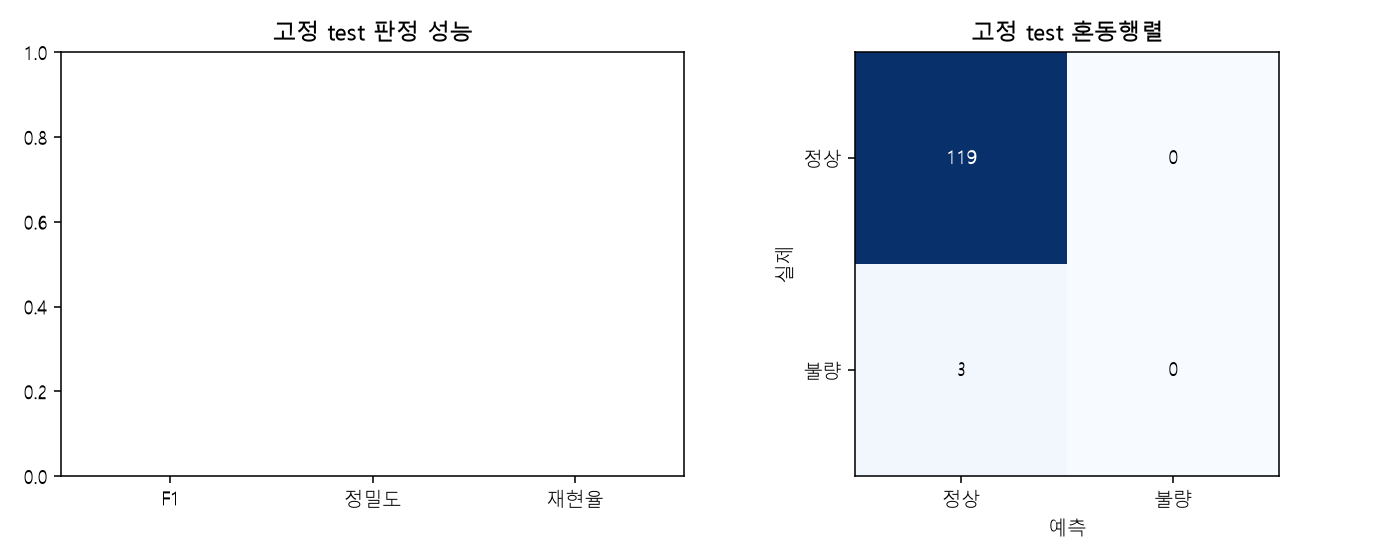

In [16]:
test_results = evaluate_fixed_test(Xdev, ydev, X.loc[test], y.loc[test], selected, OUT)
assert digest(OUT/'selection_manifest.json') == selection_sha
display(test_results[['status','scenario','threshold','F1','precision','recall','TP','FP','FN','TN','FPR','AP_reference']])
r = test_results.iloc[0]
fig, axes = plt.subplots(1,2, figsize=(10,4))
axes[0].bar(['F1','정밀도','재현율'], [r.F1,r.precision,r.recall], color='steelblue')
axes[0].set(ylim=(0,1), title='고정 test 판정 성능')
cm = np.array([[r.TN,r.FP],[r.FN,r.TP]], dtype=int)
axes[1].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2): axes[1].text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
axes[1].set(xticks=[0,1],yticks=[0,1],xticklabels=['정상','불량'],yticklabels=['정상','불량'],xlabel='예측',ylabel='실제',title='고정 test 혼동행렬')
fig.tight_layout(); fig.savefig(OUT/'test_evaluation.png', dpi=140); plt.close(fig)
display(Image(filename=str(OUT/'test_evaluation.png')))


## G. 실패 유형과 검증 기록

정상·불량 공존 패턴과 불량 전용 패턴을 구분해 탐지 결과를 확인합니다. 이는 후속 진단이며 test에 맞춰 임계값을 수정하지 않습니다.


In [17]:
metadata = pd.read_csv(ROOT/'data/processed/cn7/conservative/labeled_metadata.csv')
predictions = pd.read_csv(OUT/'test_predictions.csv')
joined = predictions.merge(metadata[['pattern_row','pattern_id','pattern_type']], on='pattern_row', validate='many_to_one')
type_results = pd.DataFrame([{'pattern_type':kind,'rows':len(part),
    **classification_metrics(part.y_true,part.y_pred)} for kind,part in joined.groupby('pattern_type')])
type_results.to_csv(OUT/'test_pattern_type_metrics.csv', index=False)
display(type_results[['pattern_type','rows','F1','TP','FN','FP','TN']])
assert all(digest(ROOT/p) == sha for p, sha in protected_hashes.items())
load_data(ROOT)
assert digest(OUT/'selection_manifest.json') == selection_sha
summary_lines = ['# CN7 validation F1 기반 선택 결과', '',
    '선택: 합산 OOF F1 최대화. 동률은 fold F1 표준편차와 입력 수로 비교.',
    'FPR 상한 없음. FPR·AP는 참고용이며 후보 제외·선택에 사용하지 않습니다.', '']
if choice['status'] == 'selected_for_followup':
    summary_lines += [f"선택: {choice['scenario']}, nu={choice['nu']:.6g}, gamma 배수={choice['gamma_multiplier']:.6g}, t={choice['threshold']:.6g}",
        f"개발 OOF F1={choice['F1']:.6f}, fold F1 표준편차={choice['F1_std']:.6f}, TP={int(choice['TP'])}, FP={int(choice['FP'])}, FN={int(choice['FN'])}"]
else: summary_lines.append('개발 F1이 양수인 후보 없음. test는 경보 없음 기준선.')
summary_lines += [f"Test F1={r.F1:.6f}, TP={r.TP}, FP={r.FP}, FN={r.FN}, TN={r.TN}", '',
    '개발 선택 성능은 낙관적일 수 있고 test도 이전에 관찰한 후속 평가입니다. 독립 성능 개선을 주장하지 않습니다.']
summary = '\n'.join(summary_lines)
(OUT/'analysis_summary.md').write_text(summary, encoding='utf-8'); print(summary)
write_json(OUT/'verification.json', {
    'all_grid_fits_converged':True,'grid_fits':expected*4,
    'selection_metric':'pooled OOF F1','FPR_used_for_selection':False,'AP_used_for_selection':False,
    'test_used_for_selection':False,'test_previously_seen':True,'selection_sha256':selection_sha,
    'fit_validation_disjoint':True,'all_train_normals_used':True,'same_selected_threshold_after_refit':True,
    'selected_oof_counts_reproduced':True,'model_reload_predictions_equal':True,
    'old_artifacts_unchanged':True,'protected_artifact_count':len(protected_hashes),
    'source_and_split_hashes_verified':True,
    'artifact_sha256':{p.name:digest(p) for p in OUT.iterdir() if p.is_file()
        and p.name not in ['verification.json','notebook_execution.json','postrun_audit.json']}})


# CN7 validation F1 기반 선택 결과

선택: 합산 OOF F1 최대화. 동률은 fold F1 표준편차와 입력 수로 비교.
FPR 상한 없음. FPR·AP는 참고용이며 후보 제외·선택에 사용하지 않습니다.

선택: legacy_without_cycle, nu=0.001, gamma 배수=0.0385388, t=0.00251189
개발 OOF F1=0.500000, fold F1 표준편차=0.000000, TP=4, FP=1, FN=7
Test F1=0.000000, TP=0, FP=0, FN=3, TN=119

개발 선택 성능은 낙관적일 수 있고 test도 이전에 관찰한 후속 평가입니다. 독립 성능 개선을 주장하지 않습니다.


,pattern_type,rows,F1,TP,FN,FP,TN
0,conflicting,3,0.0,0,3,0,0
1,normal_only,119,0.0,0,0,0,119


## H. 노트북 내부 회귀 테스트

별도 테스트 파일 없이 아래 셀에서 6개 테스트를 실행합니다. F1 계산·동률 규칙·FPR 비사용·변환·학습행 사용·임계값 유지·모델 재로딩을 확인합니다. 테스트가 만드는 실험 결과는 임시 폴더에만 저장합니다.

In [18]:
import tempfile
import unittest

class WorkflowTests(unittest.TestCase):
    def test_threshold_grid_matches_brute_force_and_ties(self):
        folds = [dict(truth=np.array([0,0,1,1]), scores=np.array([-1.,0.,0.,2.]),
                      AP_reference=.5, ROC_AUC_reference=.5),
                 dict(truth=np.array([0,1,0,1]), scores=np.array([0.,1.,2.,2.]),
                      AP_reference=.5, ROC_AUC_reference=.5)]
        trials = threshold_trials(folds, [-1.,0.,1.,2.])
        for row in trials.itertuples():
            truth = np.concatenate([f['truth'] for f in folds])
            scores = np.concatenate([f['scores'] for f in folds])
            expected = classification_metrics(truth, scores > row.threshold)
            for key in ['TP','FP','FN','TN','recall','FPR','F1']:
                self.assertEqual(expected[key], getattr(row, key))
            f1s = [classification_metrics(f['truth'], f['scores'] > row.threshold)['F1'] for f in folds]
            self.assertEqual(row.F1_std, np.std(f1s, ddof=1))
        at_zero = trials.loc[trials.threshold.eq(0.)].iloc[0]
        self.assertNotAlmostEqual(at_zero.F1, at_zero.mean_fold_F1)
        self.assertEqual(trials.iloc[-1].TP, 0)  # score == t never raises an alert
        self.assertIn(0., THRESHOLDS)
        self.assertEqual(len(THRESHOLDS), 93)
        with self.assertRaises(ValueError): threshold_trials(folds, [np.nan])

    def test_selection_uses_f1_without_fpr_or_ap_constraints(self):
        common = dict(F1_std=.1, feature_count=10, threshold=0.)
        rows = [dict(common, candidate_id=0, F1=.2, FPR=.001, mean_AP_reference=1.),
                dict(common, candidate_id=1, F1=.3, FPR=.04, mean_AP_reference=.9),
                dict(common, candidate_id=2, F1=.5, FPR=.20, mean_AP_reference=.01)]
        table = pd.DataFrame(rows)
        self.assertEqual(select_candidates(table)[0]['candidate_id'], 2)
        table['mean_AP_reference'] = [0., 0., 1.]
        table['FPR'] = [.9,.5,.99]
        self.assertEqual(select_candidates(table)[0]['candidate_id'], 2)
        table['F1'] = 0.
        self.assertEqual(select_candidates(table)[0]['status'], 'no_supported_model')

    def test_f1_ties_use_fold_f1_variation_then_feature_count(self):
        rows = [dict(F1=.5,F1_std=.2,feature_count=5,candidate_id=0,threshold=0.),
                dict(F1=.5,F1_std=.1,feature_count=12,candidate_id=1,threshold=0.),
                dict(F1=.5,F1_std=.1,feature_count=10,candidate_id=2,threshold=0.)]
        self.assertEqual(select_candidates(pd.DataFrame(rows))[0]['candidate_id'], 2)

    def test_all_scenario_transforms_and_reload(self):
        rng = np.random.default_rng(7)
        columns = sum(GROUPS.values(), [])
        normal = pd.DataFrame(rng.normal(size=(150,24)), columns=columns)
        normal['Mold_Temperature_4'] = 0.
        normal['Barrel_Temperature_6'] = 0.
        valid = pd.DataFrame(rng.normal(size=(10,24)), columns=columns)
        for scenario in SCENARIOS:
            bundle, train = fit_features(normal, scenario)
            before = bundle['normal_scaler'].mean_.copy()
            values = transform_features(bundle, valid)
            self.assertTrue(np.isfinite(values).all())
            np.testing.assert_allclose(train, transform_features(bundle, normal))
            transform_features(bundle, valid*1000)
            np.testing.assert_array_equal(before, bundle['normal_scaler'].mean_)
            if scenario == 'domain_all':
                self.assertNotIn('금형온도_상대편차', bundle['feature_names'])
                barrel = next(s for s in bundle['specs'] if s['feature']=='배럴_상대수준평균')
                self.assertNotIn('Barrel_Temperature_6', barrel['active_columns'])
            model = fit_model(train, .05, .1)
            artifact = dict(features=bundle, model=model, threshold=0.)
            with tempfile.TemporaryDirectory() as directory:
                path = Path(directory)/'model.joblib'
                joblib.dump(artifact, path)
                a = predict_artifact(artifact, valid)
                b = predict_artifact(joblib.load(path), valid)
                np.testing.assert_array_equal(a[0], b[0])
                np.testing.assert_array_equal(a[1], b[1])

    def test_split_and_development_only_smoke(self):
        root = ROOT
        x, y, assignment, dev, test, _ = load_data(root)
        xd, yd, folds = x.loc[dev], y.loc[dev], assignment.loc[dev,'cv_fold']
        plans = make_fold_plan(xd, yd, folds)
        for plan in plans:
            self.assertFalse((set(plan['fit'])|set(plan['valid'])) & set(test))
            self.assertNotIn('cal', plan)
            self.assertEqual(set(plan['fit']), set(xd.index[folds.ne(plan['fold']) & yd.eq(0)]))
            self.assertFalse(set(plan['fit']) & set(plan['valid']))
        with tempfile.TemporaryDirectory() as directory:
            table, fold_table, selected, _ = search_development(xd, yd, folds, directory,
                nu_values=[.01], multipliers=[.03], scenarios=['raw'])
            self.assertEqual(len(table), 1)
            self.assertEqual(len(fold_table), 4)
            for row in table.itertuples():
                sub = fold_table.loc[fold_table.candidate_id.eq(row.candidate_id)]
                self.assertEqual(row.TP, sub.TP.sum())
                self.assertEqual(row.FP, sub.FP.sum())
            record = __import__('json').loads((Path(directory)/'selection_manifest.json').read_text(encoding='utf-8'))
            self.assertFalse(record['AP_used_for_selection'])
            self.assertFalse(record['FPR_used_for_selection'])
            self.assertFalse(record['test_used_for_selection'])
            self.assertEqual(record['threshold_values'], THRESHOLDS)
            joint = pd.read_csv(Path(directory)/'threshold_search.csv', float_precision='round_trip')
            self.assertEqual(len(joint), len(THRESHOLDS))
            self.assertEqual(select_candidates(joint), selected)

    def test_final_fit_uses_all_normals_and_preserves_selected_t(self):
        root = ROOT
        x, y, _, dev, test, _ = load_data(root)
        choice = dict(status='selected_for_followup', scenario='raw', nu=.01,
                      gamma_multiplier=.03, threshold=.0123)
        with tempfile.TemporaryDirectory() as directory:
            p = Path(directory)
            write_json(p/'selection_manifest.json', dict(choices=[choice]))
            evaluate_fixed_test(x.loc[dev], y.loc[dev], x.loc[test], y.loc[test], [choice], p)
            artifact = joblib.load(p/'f1_selected_model.joblib')
            self.assertEqual(artifact['threshold'], choice['threshold'])
            self.assertEqual(artifact['features']['normal_scaler'].n_samples_seen_, int(y.loc[dev].eq(0).sum()))
            expected = predict_artifact(artifact, x.loc[test])
            # Alter test labels: fitting, scores and selected threshold must stay identical.
            evaluate_fixed_test(x.loc[dev], y.loc[dev], x.loc[test], 1-y.loc[test], [choice], p)
            other = joblib.load(p/'f1_selected_model.joblib')
            np.testing.assert_array_equal(expected[0], predict_artifact(other, x.loc[test])[0])
            self.assertEqual(other['threshold'], choice['threshold'])


In [19]:
test_suite = unittest.defaultTestLoader.loadTestsFromTestCase(WorkflowTests)
regression_result = unittest.TextTestRunner(stream=sys.stdout, verbosity=2).run(test_suite)
assert regression_result.wasSuccessful(), '회귀 테스트 실패'
write_json(OUT/'regression_tests.json', {
    'passed': regression_result.wasSuccessful(), 'tests_run': regression_result.testsRun,
    'failures': len(regression_result.failures), 'errors': len(regression_result.errors)})


test_all_scenario_transforms_and_reload (__main__.WorkflowTests.test_all_scenario_transforms_and_reload) ... ok
test_f1_ties_use_fold_f1_variation_then_feature_count (__main__.WorkflowTests.test_f1_ties_use_fold_f1_variation_then_feature_count) ... ok
test_final_fit_uses_all_normals_and_preserves_selected_t (__main__.WorkflowTests.test_final_fit_uses_all_normals_and_preserves_selected_t) ... ok
test_selection_uses_f1_without_fpr_or_ap_constraints (__main__.WorkflowTests.test_selection_uses_f1_without_fpr_or_ap_constraints) ... ok
test_split_and_development_only_smoke (__main__.WorkflowTests.test_split_and_development_only_smoke) ... raw: 1개 설정 × 4 folds 완료
ok
test_threshold_grid_matches_brute_force_and_ties (__main__.WorkflowTests.test_threshold_grid_matches_brute_force_and_ties) ... ok

----------------------------------------------------------------------
Ran 6 tests in 1.126s

OK


## I. 산출물 독립 재검증

전체 401,016개 조합에서 F1과 상위 20개를 다시 계산하고, OOF·test 예측과 저장 모델을 검증합니다. 아래 함수는 프로젝트 Python 모듈을 불러오지 않고 위 셀의 함수와 저장된 데이터만 사용합니다. 코드 무결성은 `.py` 파일 대신 이 노트북의 코드 셀 해시로 확인합니다.

In [20]:
def audit_saved_results():
    out = OUT
    saved_notebook = nbformat.read(NOTEBOOK_PATH, as_version=4)
    nbformat.validate(saved_notebook)
    for cell in saved_notebook.cells:
        if cell.cell_type == 'code':
            compile(cell.source, 'notebook_cell', 'exec')
    record = json.loads((out/'verification.json').read_text(encoding='utf-8'))
    assert regression_result.wasSuccessful()
    for name, expected in record['artifact_sha256'].items():
        assert digest(out/name) == expected, name
    x, y, assignment, dev, test, _ = load_data(ROOT)
    config = json.loads((out/'run_config.json').read_text(encoding='utf-8'))
    assert notebook_code_digest() == config['notebook_code_sha256']
    search = pd.read_csv(out/'candidate_search.csv', float_precision='round_trip')
    selection = json.loads((out/'selection_manifest.json').read_text(encoding='utf-8'))
    assert select_candidates(search) == selection['choices']
    assert len(search) == 7*616
    folds = pd.read_csv(out/'candidate_fold_metrics.csv', float_precision='round_trip')
    assert len(folds) == 7*616*4
    plans = json.loads((out/'fold_plan.json').read_text(encoding='utf-8'))
    for plan in plans:
        expected_fit = set(assignment.loc[assignment.partition.eq('development') &
                           assignment.cv_fold.ne(plan['fold']) & assignment.label.eq(0), 'pattern_row'])
        assert set(plan['fit']) == expected_fit and 'cal' not in plan
    final_plan = json.loads((out/'final_fit_plan.json').read_text(encoding='utf-8'))
    assert set(final_plan['fit']) == set(y.loc[dev].index[y.loc[dev].eq(0)]) and 'cal' not in final_plan
    # Independently select directly from every joint nu/gamma/t trial, not the compressed table.
    best_chunks, joint_count = [], 0
    for chunk in pd.read_csv(out/'threshold_search.csv', float_precision='round_trip', chunksize=50000):
        joint_count += len(chunk)
        # Independent scalar recomputation verifies the vectorized pooled-F1 formula.
        np.testing.assert_allclose(chunk.F1, 2*chunk.TP/(2*chunk.TP+chunk.FP+chunk.FN), rtol=0, atol=1e-15)
        best_chunks.append(rank_candidates(chunk).head(20))
    assert joint_count == 7*616*len(THRESHOLDS)
    assert select_candidates(pd.concat(best_chunks, ignore_index=True)) == selection['choices']
    expected_top = rank_candidates(pd.concat(best_chunks, ignore_index=True)).head(20).reset_index(drop=True)
    pd.testing.assert_frame_equal(expected_top, pd.read_csv(out/'top_joint_candidates.csv', float_precision='round_trip'), check_exact=True)
    oof = pd.read_csv(out/'selected_oof_predictions.csv', float_precision='round_trip')
    test_pred = pd.read_csv(out/'test_predictions.csv', float_precision='round_trip')
    test_metrics = pd.read_csv(out/'test_metrics.csv', float_precision='round_trip')
    for choice in selection['choices']:
        if choice['status'] != 'selected_for_followup': continue
        current = oof
        assert set(current.pattern_row) == set(dev) and current.pattern_row.is_unique
        assert np.array_equal((current.risk_score > current.threshold).astype(int), current.y_pred)
        metrics = classification_metrics(current.y_true, current.y_pred)
        assert all(metrics[k] == choice[k] for k in ['TP','FP','TN','FN'])
        assert metrics['F1'] == choice['F1']
        selected_fold = folds.loc[folds.candidate_id.eq(choice['candidate_id'])]
        assert np.isclose(selected_fold.F1.std(ddof=1), choice['F1_std'])
        assert current.threshold.eq(choice['threshold']).all()
        artifact = joblib.load(out/'f1_selected_model.joblib')
        scores, pred = predict_artifact(artifact, x.loc[test])
        saved = test_pred
        assert np.array_equal(saved.pattern_row, test)
        np.testing.assert_array_equal(scores, saved.risk_score.to_numpy())
        np.testing.assert_array_equal(pred, saved.y_pred.to_numpy())
        observed = classification_metrics(y.loc[test], pred)
        saved_metrics = test_metrics.iloc[0]
        for key, value in observed.items():
            assert np.isclose(value, saved_metrics[key])
        assert artifact['selection_sha256'] == digest(out/'selection_manifest.json')
        assert artifact['threshold'] == choice['threshold']
        assert artifact['features']['normal_scaler'].n_samples_seen_ == len(final_plan['fit'])
    summary = dict(passed=True, all_code_cells_compile=True, complete_grid=True,
                   artifact_hashes_match=True, independent_model_reload_equal=True,
                   selection_reproduced_without_test=True, metrics_recomputed=True,
                   project_python_imports_required=False, all_normal_train_rows_used=True,
                   fixed_validation_threshold_preserved=True, full_joint_grid_verified=joint_count,
                   F1_selection_and_top20_reproduced=True, FPR_used_for_selection=False,
                   unit_tests_passed=regression_result.testsRun)
    write_json(out/'postrun_audit.json', summary)
    print(json.dumps(summary, indent=2))


In [21]:
audit_saved_results()


{
  "passed": true,
  "all_code_cells_compile": true,
  "complete_grid": true,
  "artifact_hashes_match": true,
  "independent_model_reload_equal": true,
  "selection_reproduced_without_test": true,
  "metrics_recomputed": true,
  "project_python_imports_required": false,
  "all_normal_train_rows_used": true,
  "fixed_validation_threshold_preserved": true,
  "full_joint_grid_verified": 401016,
  "F1_selection_and_top20_reproduced": true,
  "FPR_used_for_selection": false,
  "unit_tests_passed": 6
}
